# AI kunskapskontroll 2026 del 2

## EDA

## Start by loading & describing

In [54]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

In [55]:

#If as_frame is False, the data and target will be NumPy arrays and the data will only contain numerical values when parser="liac-arff" where the categories are provided in the attribute categories of the Bunch instance. When parser="pandas", no ordinal encoding is made.
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
print(mnist.DESCR)
#The 784 number is not fundamental. It’s just: 28×28 pixels stored as a 1D vector
print(mnist.data.shape)

X = mnist.data
y = mnist.target



**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

## Is our data balanced?

<Axes: >

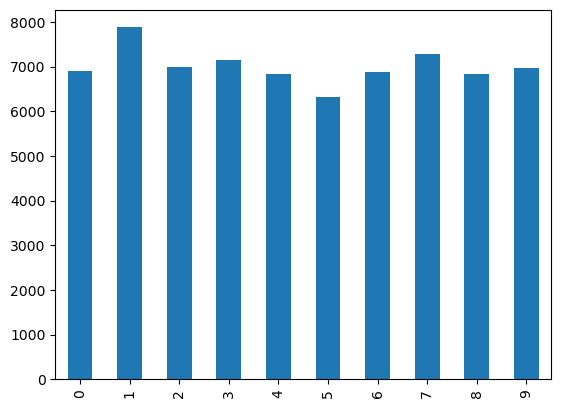

In [75]:
# Class distribution: how many samples of every picture is in the dataset?
pd.Series(y).value_counts().sort_index().plot(kind="bar")



Text(0.5, 1.0, 'Pixel intensity distribution')

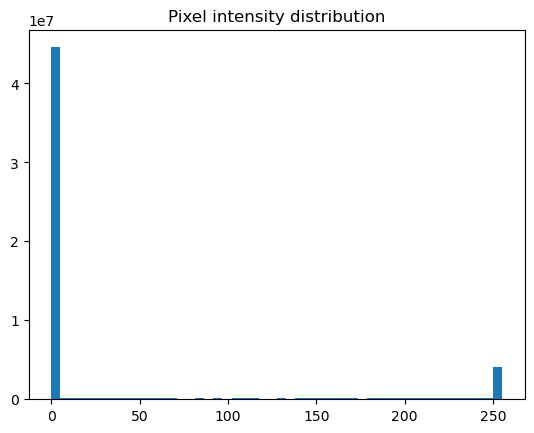

In [76]:

# looks weird cause its black and white and almost nothing else
plt.hist(X.flatten(), bins=50)
plt.title("Pixel intensity distribution")


## Visualize all. Average image per digit

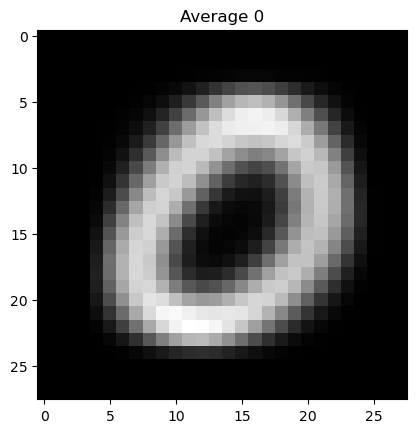

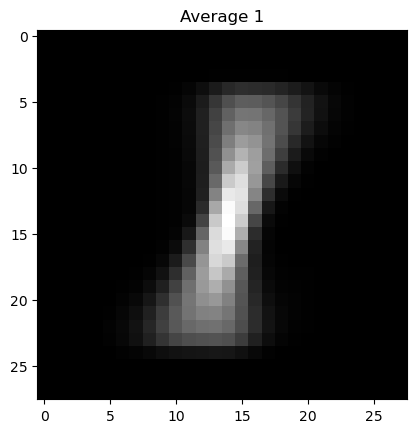

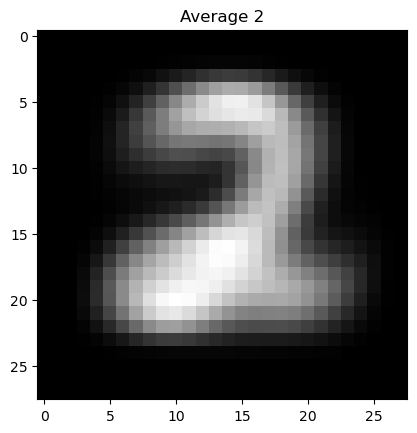

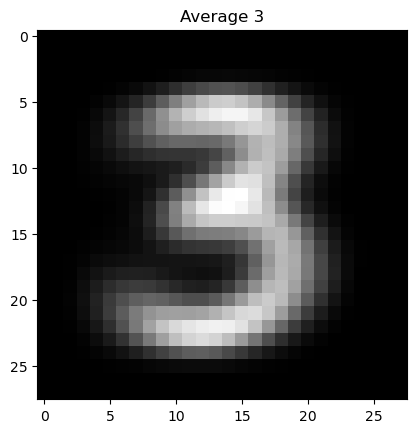

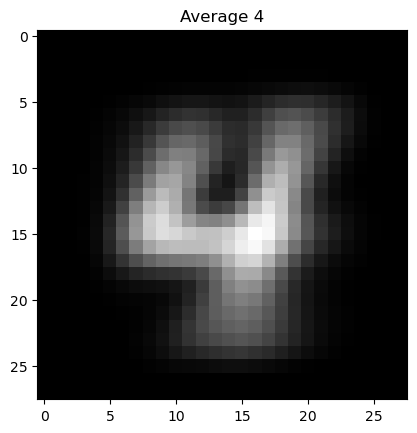

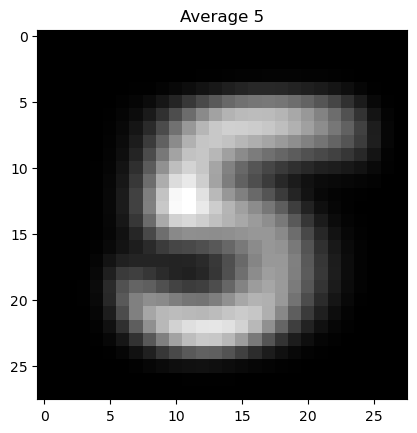

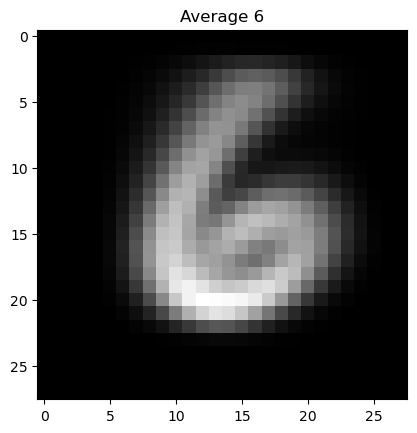

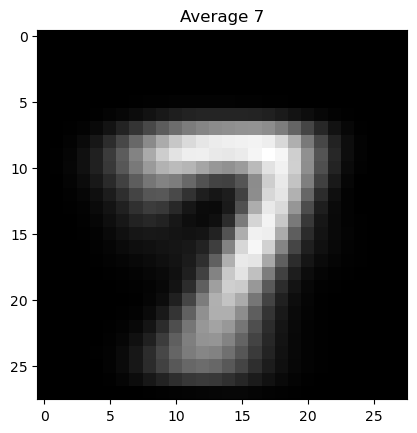

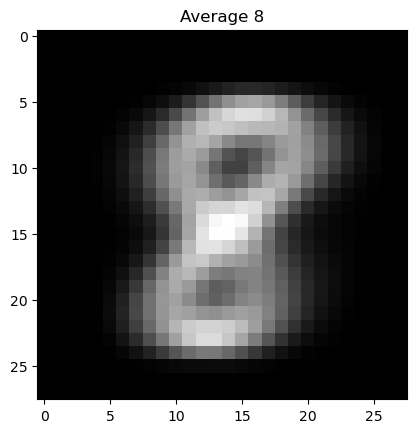

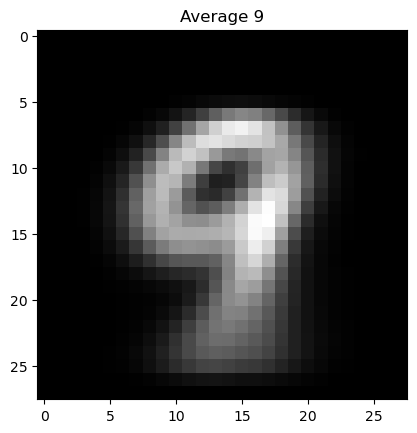

In [77]:
for digit in range(10):
    plt.imshow(X[(y.astype(int))==digit].mean(axis=0).reshape(28,28), cmap="gray")
    plt.title(f"Average {digit}")
    plt.show()

## Split data into train, valid, test

In [78]:
from sklearn.model_selection import train_test_split

import os
import joblib
X_scaled = X / 255.0 #unscaled aborted with some error after minutes of training
y = y.astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)





## Step Training:

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

#LG
linreg_model = LogisticRegression(max_iter=1000)
linreg_model.fit(X_train, y_train)


#SVC
#svc_model = SVC(kernel="rbf")
#svc_model.fit(X_train, y_train)

svc_model_path = 'mnist_svc_model.joblib'
if (os.path.exists(svc_model_path)):
    print("Loading SVC model from file...")
    svc_model = joblib.load(svc_model_path)
else:
    print("Training SVC model...")
    svc_model.fit(X_train, y_train)
    joblib.dump(svc_model, svc_model_path)
    print("SVC model saved to file.")
    

# CNN: use scaled data but reshaped
X_train_cnn = X_train.reshape(-1, 28, 28, 1)  # Still scaled, just different shape
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
model_cnn.fit(X_train_cnn, y_train)  # Shape: (samples, 28, 28, 1)


Loading SVC model from file...
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9845 - loss: 0.0479


In [71]:
# prepare and train CNN model
# Import necessary libraries
%pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Prepare data for CNN (scaled and reshaped)
X_scaled = X / 255.0

# Reshape for CNN: (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Build CNN model
model_cnn = keras.Sequential([
    # First convolutional block
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Second convolutional block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes (digits 0-9)
])

# Compile the model
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model_cnn.summary()

history = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Note: you may need to restart the kernel to use updated packages.


c:\Users\alexa\.conda\envs\CondaPython3_13_lab12\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9071 - loss: 0.3068 - val_accuracy: 0.9753 - val_loss: 0.0812
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9721 - loss: 0.0910 - val_accuracy: 0.9814 - val_loss: 0.0590
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9792 - loss: 0.0659 - val_accuracy: 0.9874 - val_loss: 0.0439
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9829 - loss: 0.0545 - val_accuracy: 0.9892 - val_loss: 0.0367
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9850 - loss: 0.0468 - val_accuracy: 0.9896 - val_loss: 0.0338
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9864 - loss: 0.0425 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9882 - loss: 0.0370 - val_accuracy: 0.9904 - val_loss: 0.0302
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9894 - loss: 0.0334 - val_accu

## Step Evaluation:

In [72]:
from sklearn.metrics import root_mean_squared_error
rmse_linreg = root_mean_squared_error(y_test, linreg_model.predict(X_test))
print(f"RMSE for Logistic Regression: {rmse_linreg}")
accuracy_linreg = linreg_model.score(X_test, y_test)
print(f"Accuracy for Logistic Regression: {accuracy_linreg:.4f}")

rmse_svc = root_mean_squared_error(y_test, svc_model.predict(X_test))
print(f"RMSE for SVC: {rmse_svc}")
accuracy_svc = svc_model.score(X_test, y_test)
print(f"Accuracy for SVC: {accuracy_svc:.4f}")

# Evaluate CNN model
test_loss, test_acc = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test accuracy for CNN: {test_acc:.4f}")


RMSE for Logistic Regression: 1.17667813295371
Accuracy for Logistic Regression: 0.9201
RMSE for SVC: 0.6617617180137965
Accuracy for SVC: 0.9764
Test accuracy for CNN: 0.9906


In [73]:
# First create the predictions
y_pred_lr = linreg_model.predict(X_test)

# Check what you're comparing
print("Type of y_test:", type(y_test[0]))
print("Sample y_test values:", y_test[:5])
print("Type of predictions:", type(y_pred_lr[0]))
print("Sample predictions:", y_pred_lr[:5])
print("Do they match?", y_test[0] == y_pred_lr[0])

Type of y_test: <class 'numpy.int64'>
Sample y_test values: [8 4 8 7 7]
Type of predictions: <class 'numpy.int64'>
Sample predictions: [8 4 5 7 7]
Do they match? True
